In [1]:
import pandas as pd

In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = "/content/drive/MyDrive/Diseases"
print("Classes:", os.listdir(path))

Classes: ['StripeCanker', 'RoughBark']


**Data Preprocessing**

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2 # Automatically splits the folder
)

In [7]:
train_generator = train_datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 16 images belonging to 2 classes.


In [8]:
val_generator = train_datagen.flow_from_directory(
    path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 3 images belonging to 2 classes.


**Build the Model (Transfer Learning)**

In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

**Train the Model**

In [11]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 0.6250 - loss: 0.7057 - val_accuracy: 1.0000 - val_loss: 5.6232e-04
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 0.0029 - val_accuracy: 1.0000 - val_loss: 5.5787e-05
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 8.9185e-05 - val_accuracy: 1.0000 - val_loss: 5.1657e-07
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 1.3761e-05 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 1.0000 - loss: 2.4587e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 1.0000 - loss: 1.1176e-07 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 1.4901e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 1.0000 - loss: 2.9802e-08 - va

**Visulize Training Performance**

In [12]:
import matplotlib.pyplot as plt

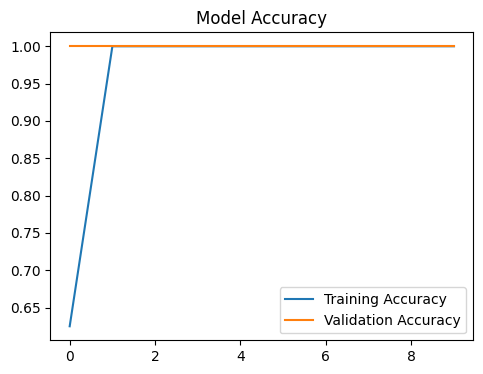

In [13]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

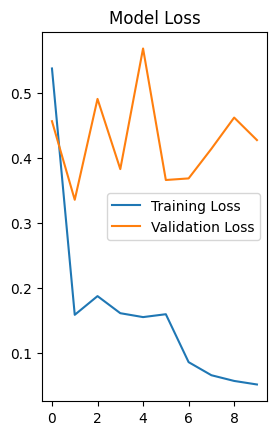

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [ ]:
#F1 Score

**Test with a image**

In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

In [ ]:
uploaded = files.upload()

for fn in uploaded.keys():
    # 2. Preprocess the image to match model input
    img_path = fn
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize like training

    # 3. Make the prediction
    predictions = model.predict(img_array)

    # 4. Get the result
    class_names = list(train_generator.class_indices.keys())
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    print(f"\n--- Prediction Results ---")
    print(f"File: {fn}")
    print(f"Predicted Disease: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

Saving testsdgp.jpg to testsdgp.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

--- Prediction Results ---
File: testsdgp.jpg
Predicted Disease: RoughBark
Confidence: 99.95%


In [15]:
model.save('cinnamon_disease_model.keras')
print("Model saved to Colab disk as 'cinnamon_disease_model.keras'")

Model saved to Colab disk as 'cinnamon_disease_model.keras'


In [16]:
import tensorflow as tf

# 1. Initialize the TFLite converter from the Keras model
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# 2. Convert the model
tflite_model = converter.convert()

# 3. Save the converted model to disk
tflite_filename = 'cinnamon_disease_model.tflite'
with open(tflite_filename, 'wb') as f:
    f.write(tflite_model)

print(f"Model converted and saved as '{tflite_filename}'")

Saved artifact at '/tmp/tmpbakv94a7'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  137483501075728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501930640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501931024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501075920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501076304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501074768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501929680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501931792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501931408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137483501931216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1374835019

In [ ]:
# Extract the class names from the training generator
# Assuming you used train_generator = train_datagen.flow_from_directory(...)
labels = list(train_generator.class_indices.keys())

# Save labels to a .txt file
label_filename = 'labels.txt'
with open(label_filename, 'w') as f:
    for label in labels:
        f.write(label + '\n')

print(f"Labels saved as '{label_filename}'")
# For verification, print the order:
print("Label order:", labels)

Labels saved as 'labels.txt'
Label order: ['RoughBark', 'StripeCanker']


In [14]:
from google.colab import files

# Download the TFLite model
files.download(tflite_filename)

# Download the labels file
files.download(label_filename)

print("Download prompts triggered for model and label files.")

NameError: name 'tflite_filename' is not defined

ROC Curve

Data augmentation